<h1>Obraz binarny</h1>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import matplotlib.animation as animation

Najpierw potrzebujemy funkcji generującej mapę

In [3]:
def generate_binary_map(n, density):
    total_pixels = n * n
    num_black_pixels = int(total_pixels * density)

    flat_image = np.concatenate([np.ones(num_black_pixels), 
                                 np.zeros(total_pixels - num_black_pixels)])


    np.random.shuffle(flat_image)

    binary_map = flat_image.reshape((n, n))
    
    return binary_map

In [15]:
def visualize_comparison(map_start, map_end, label):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    axes[0].imshow(map_start, cmap='binary', interpolation='nearest')
    axes[0].set_title("Initial Map", fontsize=15)
    axes[0].axis('off')
    
    axes[1].imshow(map_end, cmap='binary', interpolation='nearest')
    axes[1].set_title(label, fontsize=15)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

<h4>Funkcji energii dla 4 sąsiadów<h4>

In [8]:
def temp_exp(iteration, initial_t, par):
    return initial_t * (par ** iteration)


def calculate_total_energy(image, energy_func):
    total_e = 0
    rows, cols = image.shape
    
    for r in range(rows):
        for c in range(cols):
            total_e += energy_func(image, r, c)


    return total_e 

In [31]:
def simulated_annealing(initial_image, energy_func, initial_temp, cooling_rate, num_steps):
    current_image = initial_image.copy()
    

    black_coords = list(map(tuple, np.argwhere(current_image == 1)))
    white_coords = list(map(tuple, np.argwhere(current_image == 0)))
    
    current_temp = initial_temp
    current_total_energy = calculate_total_energy(current_image, energy_func)
    
    best_image = current_image.copy()
    best_energy = current_total_energy
    
    energies_history = []
    temps_history = []
    images_history = []
    
    for step in range(num_steps):
        b_idx = random.randint(0, len(black_coords) - 1)
        w_idx = random.randint(0, len(white_coords) - 1)
        
        b_r, b_c = black_coords[b_idx]
        w_r, w_c = white_coords[w_idx]
        
        energy_before = energy_func(current_image, b_r, b_c) + energy_func(current_image, w_r, w_c)
        
        current_image[b_r, b_c] = 0
        current_image[w_r, w_c] = 1
        
        energy_after = energy_func(current_image, b_r, b_c) + energy_func(current_image, w_r, w_c)
        
        delta_e = energy_after - energy_before
        
        accept = False
        if delta_e < 0: accept = True 
        elif current_temp > 0: 
            probability = math.exp(-delta_e / current_temp)
            if random.random() < probability: accept = True
        
        if accept:
            current_total_energy += delta_e
            
            black_coords[b_idx] = (w_r, w_c)
            white_coords[w_idx] = (b_r, b_c)
            
            if current_total_energy < best_energy:
                best_energy = current_total_energy
                best_image = current_image.copy()
        else:
            current_image[b_r, b_c] = 1
            current_image[w_r, w_c] = 0
            
        energies_history.append(current_total_energy)
        temps_history.append(current_temp)
        
        if step % 3000 == 0: images_history.append(current_image.copy())
            
        current_temp = temp_exp(step, initial_temp, cooling_rate)
        
    return best_image, best_energy, energies_history, temps_history, images_history

size = 200
density = 0.3
initial_map = generate_binary_map(size, density)

# best_img, best_e, energies, temps, history = simulated_annealing(
#     initial_image=initial_map, 
#     energy_func=energy_islands, 
#     initial_temp=100.0, 
#     cooling_rate=0.999, 
#     num_steps=600000
# )



In [ ]:
def energy_islands_4n(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    neighbors = [
        image[(r - 1) % rows, c],
        image[(r + 1) % rows, c], 
        image[r, (c - 1) % cols], 
        image[r, (c + 1) % cols]  
    ]
    
    energy = 0
    for n in neighbors:
        if n == pixel_color: energy -= 1 
        else: energy += 1 
            
    return energy


def energy_anisotropy_4n(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    top = image[(r - 1) % rows, c]
    bottom = image[(r + 1) % rows, c]
    left = image[r, (c - 1) % cols]
    right = image[r, (c + 1) % cols]
    
    energy = 0
    
    for n in [left, right]:
        if n == pixel_color:
            energy -= 5 
        else:
            energy += 5
            
    for n in [top, bottom]:
        if n == pixel_color:
            energy += 5 
        else:
            energy -= 5
            
    return energy


def energy_checkerboard_4n(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    neighbors = [
        image[(r - 1) % rows, c], 
        image[(r + 1) % rows, c], 
        image[r, (c - 1) % cols], 
        image[r, (c + 1) % cols]  
    ]
    
    energy = 0
    for n in neighbors:
        if n != pixel_color: energy -= 1 
        else: energy += 1 
            
    return energy
        

In [ ]:
def generate_annealing_gif(images_history, filename, label):

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axis('off')

    im = ax.imshow(images_history[0], cmap='binary', interpolation='nearest')
    title = ax.set_title(label, fontsize=14)

    def update(frame_idx):
        im.set_array(images_history[frame_idx])
        return [im, title]

    ani = animation.FuncAnimation(
        fig, 
        update, 
        frames=len(images_history), 
        blit=True 
    )

    writer = animation.PillowWriter()
    ani.save(filename, writer=writer)
    
    plt.close() 
    

size = 200
density = 0.4
initial_map = generate_binary_map(size, density)


-6088
-3160
6088


In [32]:
best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_islands_4n, 
    initial_temp=100.0, 
    cooling_rate=0.999, 
    num_steps=600000
)

generate_annealing_gif(history, filename="./GIFs/islands_4n.gif", label="islands_4n")


![Animacja TSP](GIFs/islands_4n.gif).

In [29]:
best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_anisotropy_4n, 
    initial_temp=100.0, 
    cooling_rate=0.999, 
    num_steps=600000
)

generate_annealing_gif(history, filename="./GIFs/anistropy_4n.gif", label="anistropy_4n")



-3160


![Animacja TSP](GIFs/anistropy_4n.gif).

In [30]:
best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_checkerboard_4n, 
    initial_temp=100.0, 
    cooling_rate=0.999, 
    num_steps=600000
)
generate_annealing_gif(history, filename="./GIFs/checkerboard_4n.gif", label="checkerboard_4n")


6088


![Animacja TSP](GIFs/checkerboard_4n.gif).

<h4>Funkcji dla 8-sąsiedstwa</h4>

In [ ]:

def energy_physical_realism(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    straights = [
        image[(r - 1) % rows, c], 
        image[(r + 1) % rows, c], 
        image[r, (c - 1) % cols], 
        image[r, (c + 1) % cols]  
    ]
    
    diagonals = [
        image[(r - 1) % rows, (c - 1) % cols], 
        image[(r - 1) % rows, (c + 1) % cols], 
        image[(r + 1) % rows, (c - 1) % cols], 
        image[(r + 1) % rows, (c + 1) % cols]  
    ]
    
    energy = 0
    
    for n in straights:
        if n == pixel_color: energy -= 2
        else: energy += 2
            
    for n in diagonals:
        if n == pixel_color: energy -= 1
        else: energy += 1
            
    return energy


def energy_diagonal_rain(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    good_diags = [
        image[(r - 1) % rows, (c - 1) % cols], 
        image[(r + 1) % rows, (c + 1) % cols]  
    ]
    
    bad_diags = [
        image[(r - 1) % rows, (c + 1) % cols], 
        image[(r + 1) % rows, (c - 1) % cols]  
    ]
    
    energy = 0
    
    for n in good_diags:
        if n == pixel_color: energy -= 2
        else: energy += 2
            
    for n in bad_diags:
        if n == pixel_color: energy += 2
        else: energy -= 2
            
    return energy


def energy_foam(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    neighbors = [
        image[(r - 1) % rows, c],               
        image[(r + 1) % rows, c],               
        image[r, (c - 1) % cols],               
        image[r, (c + 1) % cols],               
        image[(r - 1) % rows, (c - 1) % cols],  
        image[(r - 1) % rows, (c + 1) % cols],  
        image[(r + 1) % rows, (c - 1) % cols],  
        image[(r + 1) % rows, (c + 1) % cols]   
    ]
    
    same_color_count = sum(1 for n in neighbors if n == pixel_color)
    
    if same_color_count <= 2: return 10

    elif same_color_count in [3, 4, 5]: return -5

    elif same_color_count == 8: return 10

    else: return 0
    
def energy_pentagonal(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    pentagon_neighbors = [
        image[r, (c - 1) % cols],              
        image[r, (c + 1) % cols],              
        image[(r - 1) % rows, (c - 1) % cols], 
        image[(r - 1) % rows, c],              
        image[(r - 1) % rows, (c + 1) % cols]  
    ]
    
    excluded_neighbors = [
        image[(r + 1) % rows, (c - 1) % cols], 
        image[(r + 1) % rows, c],              
        image[(r + 1) % rows, (c + 1) % cols]  
    ]
    
    energy = 0
    
    for n in pentagon_neighbors:
        if n == pixel_color: energy -= 2
        else: energy += 2
            
    for n in excluded_neighbors:
        if n == pixel_color: energy += 2
        else: energy -= 2
            
    return energy

def energy_snake(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    direct_neighbors = [
        image[(r - 1) % rows, c],
        image[(r + 1) % rows, c], 
        image[r, (c - 1) % cols], 
        image[r, (c + 1) % cols]  
    ]
    
    diagonal_neighbors = [
        image[(r - 1) % rows, (c - 1) % cols], 
        image[(r - 1) % rows, (c + 1) % cols], 
        image[(r + 1) % rows, (c - 1) % cols], 
        image[(r + 1) % rows, (c + 1) % cols]  
    ]
    
    energy = 0
    
    same_direct = sum(1 for n in direct_neighbors if n == pixel_color)
    
    if same_direct == 2: energy -= 6 
    elif same_direct == 1: energy -= 2 
    else: energy += 8 
        

    for n in diagonal_neighbors:
        if n == pixel_color: energy += 3
        else: energy -= 1
            
    return energy



def energy_snake_grid(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    energy = 0
    
    for dx in range(-6, 7):
        for dy in range(-6, 7):
            if dx == 0 and dy == 0: continue
                
            if (dx % 3 == 0 and abs(dy) <= 1) or (dy % 3 == 0 and abs(dx) <= 1):
                weight = 3  
            else:
                weight = -1 
                
            n_r = (r + dx) % rows
            n_c = (c + dy) % cols
            
            if image[n_r, n_c] == pixel_color: energy -= weight
            else: energy += weight
                
    return energy

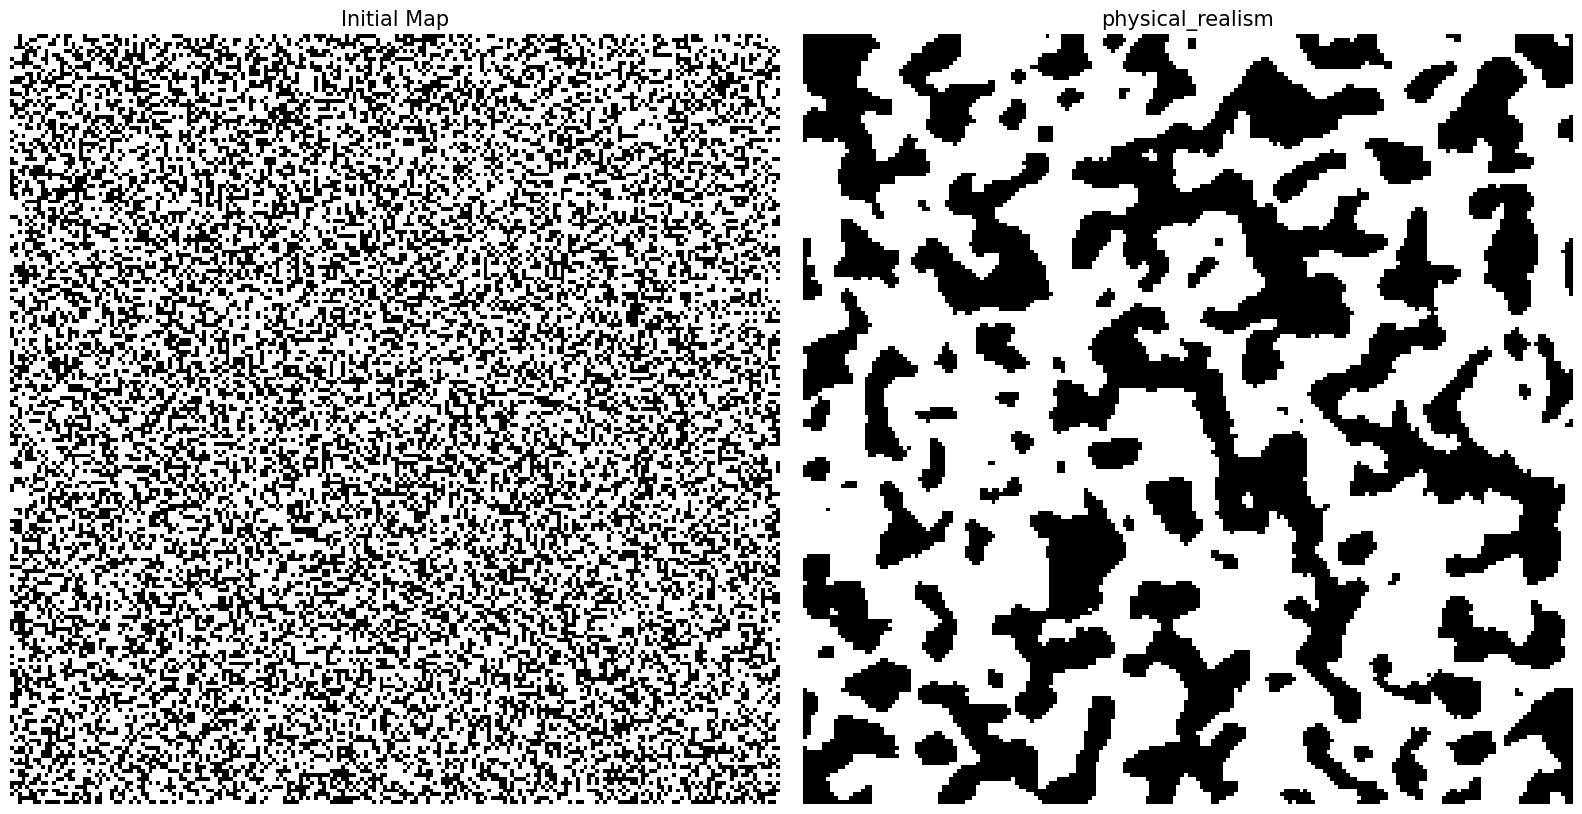

In [36]:

size = 200
density = 0.4
initial_map = generate_binary_map(size, density)

best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_physical_realism, 
    initial_temp=500.0, 
    cooling_rate=0.99988, 
    num_steps=1000000
)

visualize_comparison(initial_map, best_img, label="physical_realism")


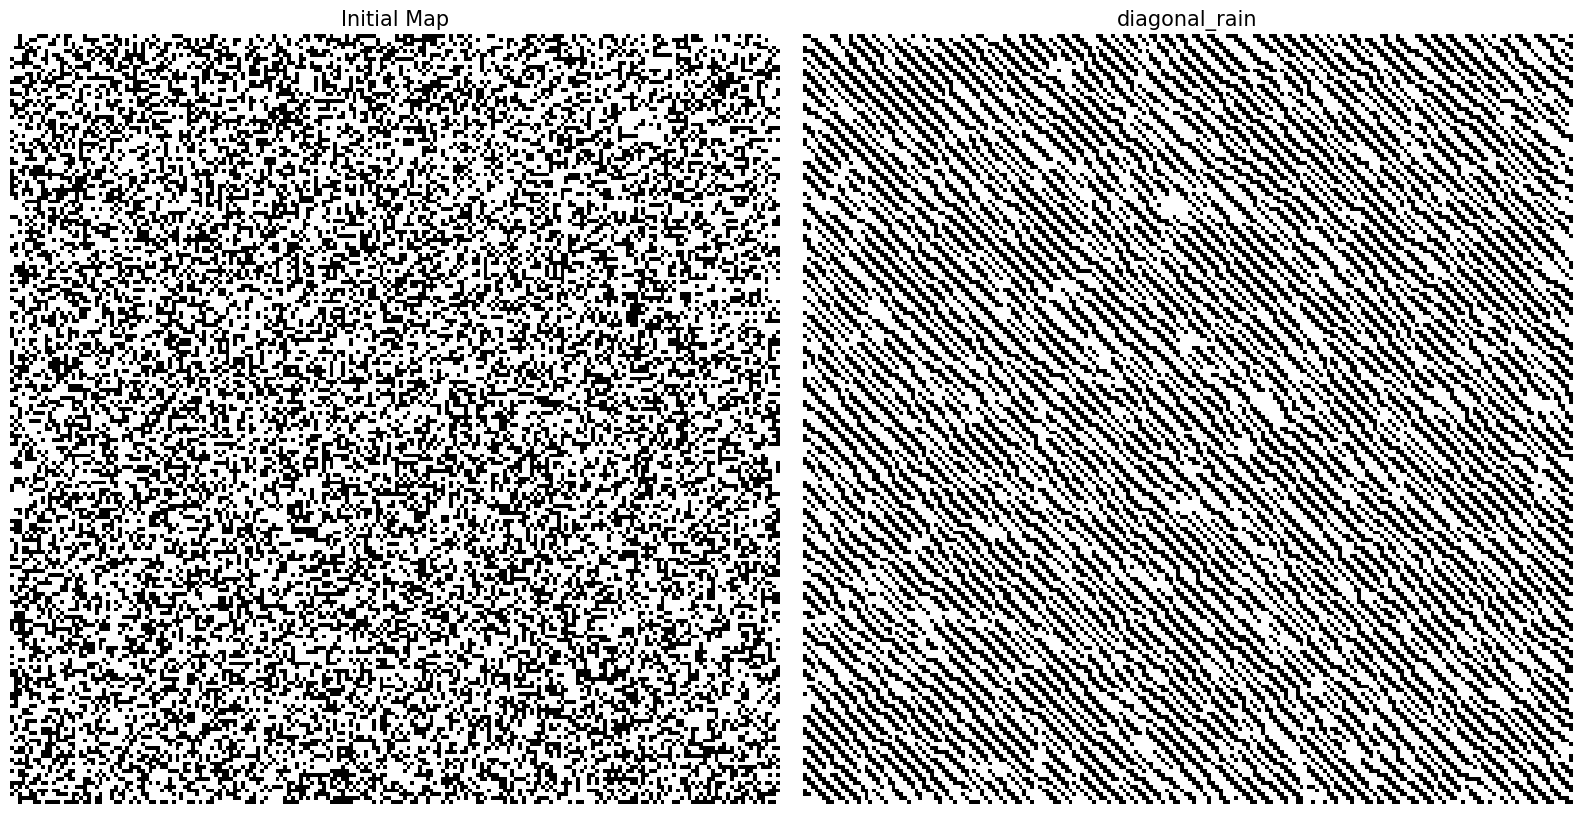

In [38]:
best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_diagonal_rain, 
    initial_temp=500.0, 
    cooling_rate=0.99988, 
    num_steps=1000000
)

visualize_comparison(initial_map, best_img, label="diagonal_rain")

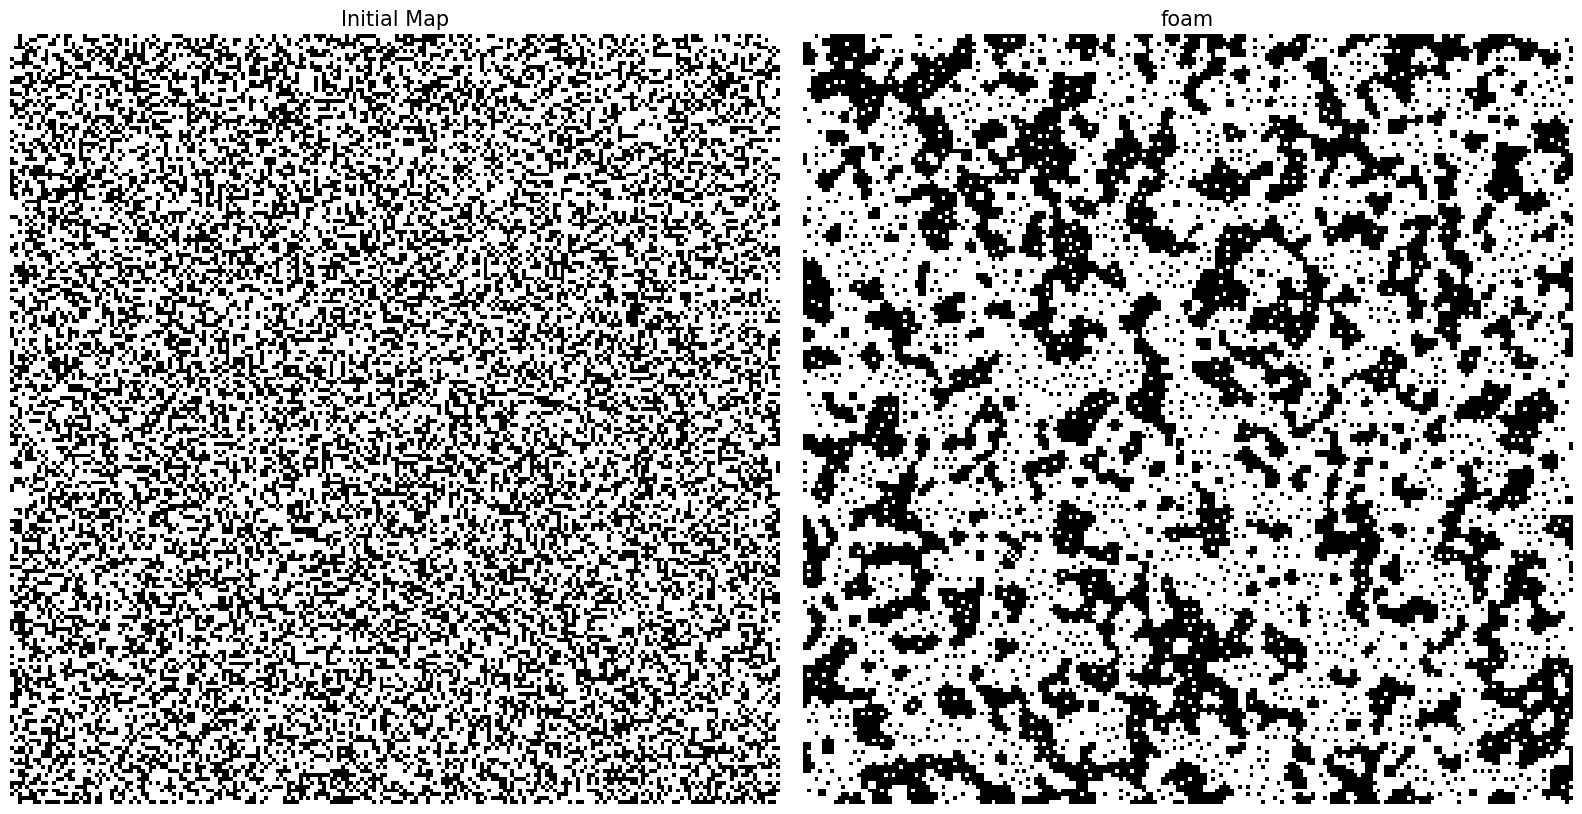

In [42]:
best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_foam, 
    initial_temp=500.0, 
    cooling_rate=0.9988, 
    num_steps=1000000
)

visualize_comparison(initial_map, best_img, label="foam")

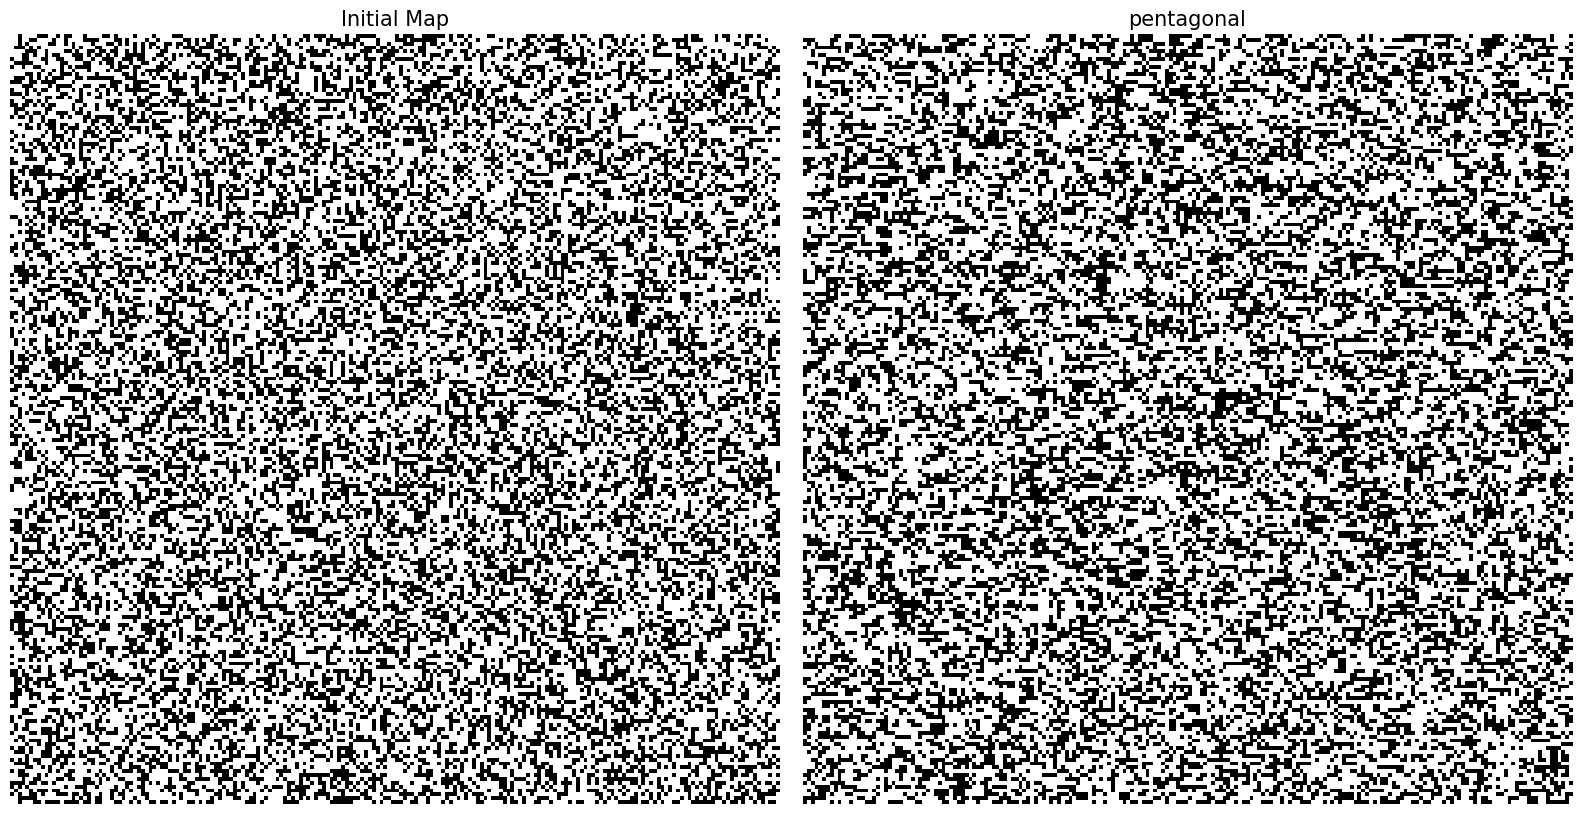

In [46]:
best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_pentagonal, 
    initial_temp=1000.0, 
    cooling_rate=0.99988, 
    num_steps=1000000
)

visualize_comparison(initial_map, best_img, label="pentagonal")

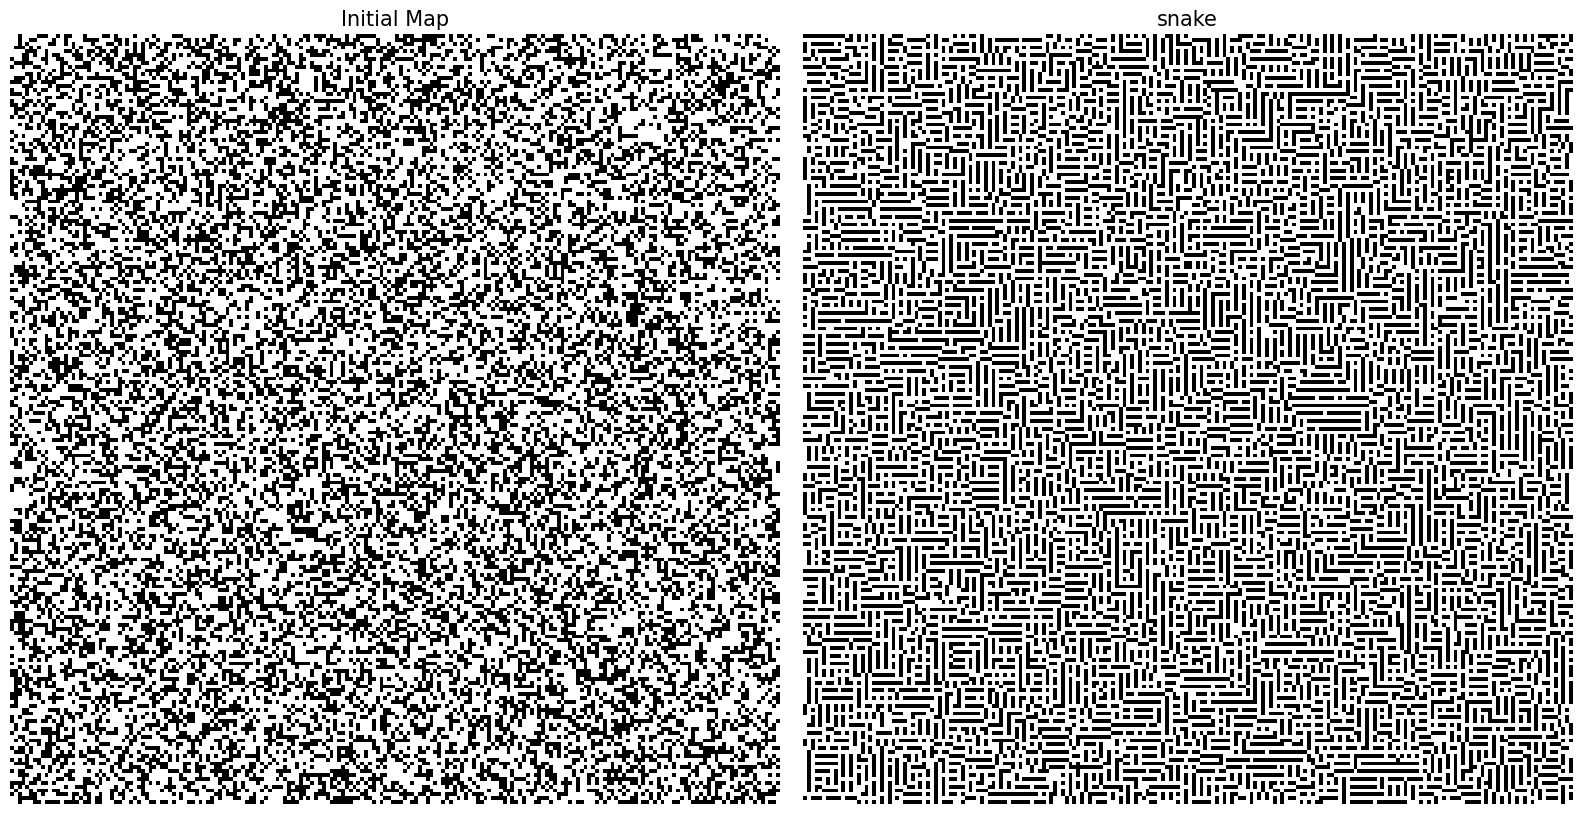

In [48]:
best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_snake, 
    initial_temp=1000.0, 
    cooling_rate=0.99988, 
    num_steps=600000
)

visualize_comparison(initial_map, best_img, label="snake")

In [49]:
best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_snake_grid, 
    initial_temp=1000.0, 
    cooling_rate=0.99988, 
    num_steps=600000
)

visualize_comparison(initial_map, best_img, label="snake_grid")

KeyboardInterrupt: 

In [ ]:
def energy_foa2(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    same_color_count = 0
    
    # Count ALL same-colored neighbors in the 8-16 neighborhood (5x5)

    #от 2 до 3
    for dx in range(-4, 3):
        for dy in range(-2, 3):
            if dx == 0 and dy == 0:
                continue
                
            n_r = (r + dx) % rows
            n_c = (c + dy) % cols
            
            if image[n_r, n_c] == pixel_color:
                same_color_count += 1
                
    # Non-linear energy function
    # The ideal number of same-colored neighbors is exactly 7 (out of 24)
    target_neighbors = 7
    
    # Energy is the absolute distance from the ideal state
    # If count is 7, energy is 0 (perfect!). If count is 24, energy is huge (terrible!)
    energy = abs(same_color_count - target_neighbors) * 2
    
    return energy

def energy_fingerprint(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    energy = 0
    
    # 5x5 window (8-16 neighborhood)
    for dx in range(-4, 3):
        for dy in range(-4, 3):
            if dx == 0 and dy == 0:
                continue
                
            n_r = (r + dx) % rows
            n_c = (c + dy) % cols
            
            # Anisotropy: Horizontal-ish lines attract, Vertical-ish lines repel
            # We use absolute distance to determine orientation
            if abs(dy) > abs(dx):
                weight = 2   # Strong horizontal attraction
            elif abs(dx) > abs(dy):
                weight = -2  # Strong vertical repulsion
            else:
                weight = 0   # Neutrals on exact diagonals
                
            if image[n_r, n_c] == pixel_color:
                energy -= weight
            else:
                energy += weight
                
    return energy

def energy_quantum_dots(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    energy = 0
    
    for dx in range(-4, 3):
        for dy in range(-4, 3):
            if dx == 0 and dy == 0:
                continue
                
            n_r = (r + dx) % rows
            n_c = (c + dy) % cols
            
            # Distance 1 means inner ring (8 neighbors)
            # Distance 2 means outer ring (16 neighbors)
            distance = max(abs(dx), abs(dy))
            
            if distance == 1:
                weight = -4 # HUGE repulsion for immediate contact
            elif distance == 2:
                weight = 1  # Mild attraction at a distance
                
            if image[n_r, n_c] == pixel_color:
                energy -= weight
            else:
                energy += weight
                
    return energy

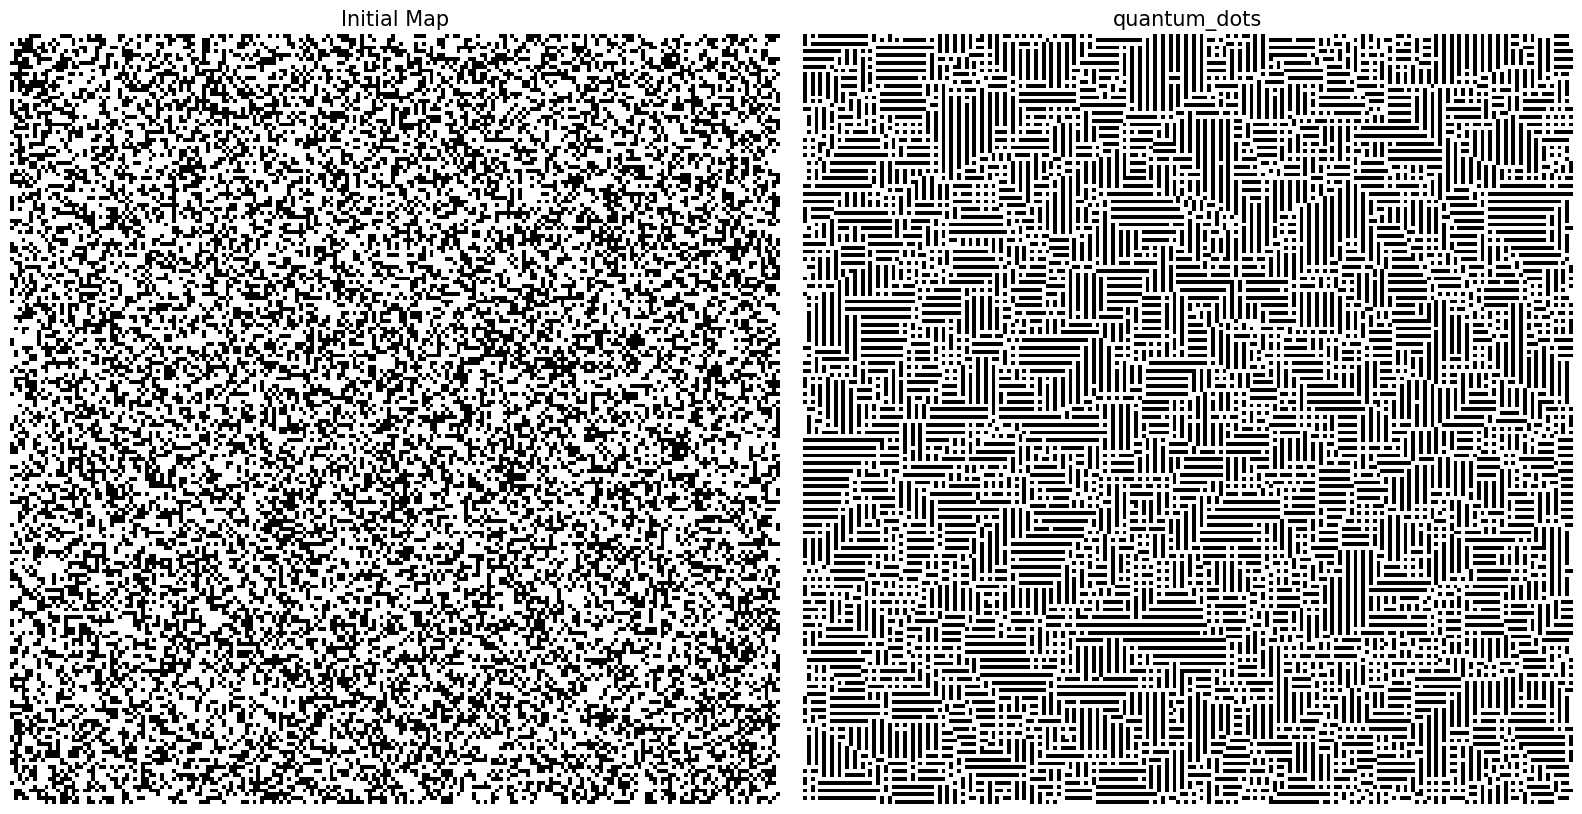

In [59]:
size = 200
density = 0.4
initial_map = generate_binary_map(size, density)

best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_quantum_dots, 
    initial_temp=100.0, 
    cooling_rate=0.99988, 
    num_steps=600000
)
visualize_comparison(initial_map, best_img, "quantum_dots")


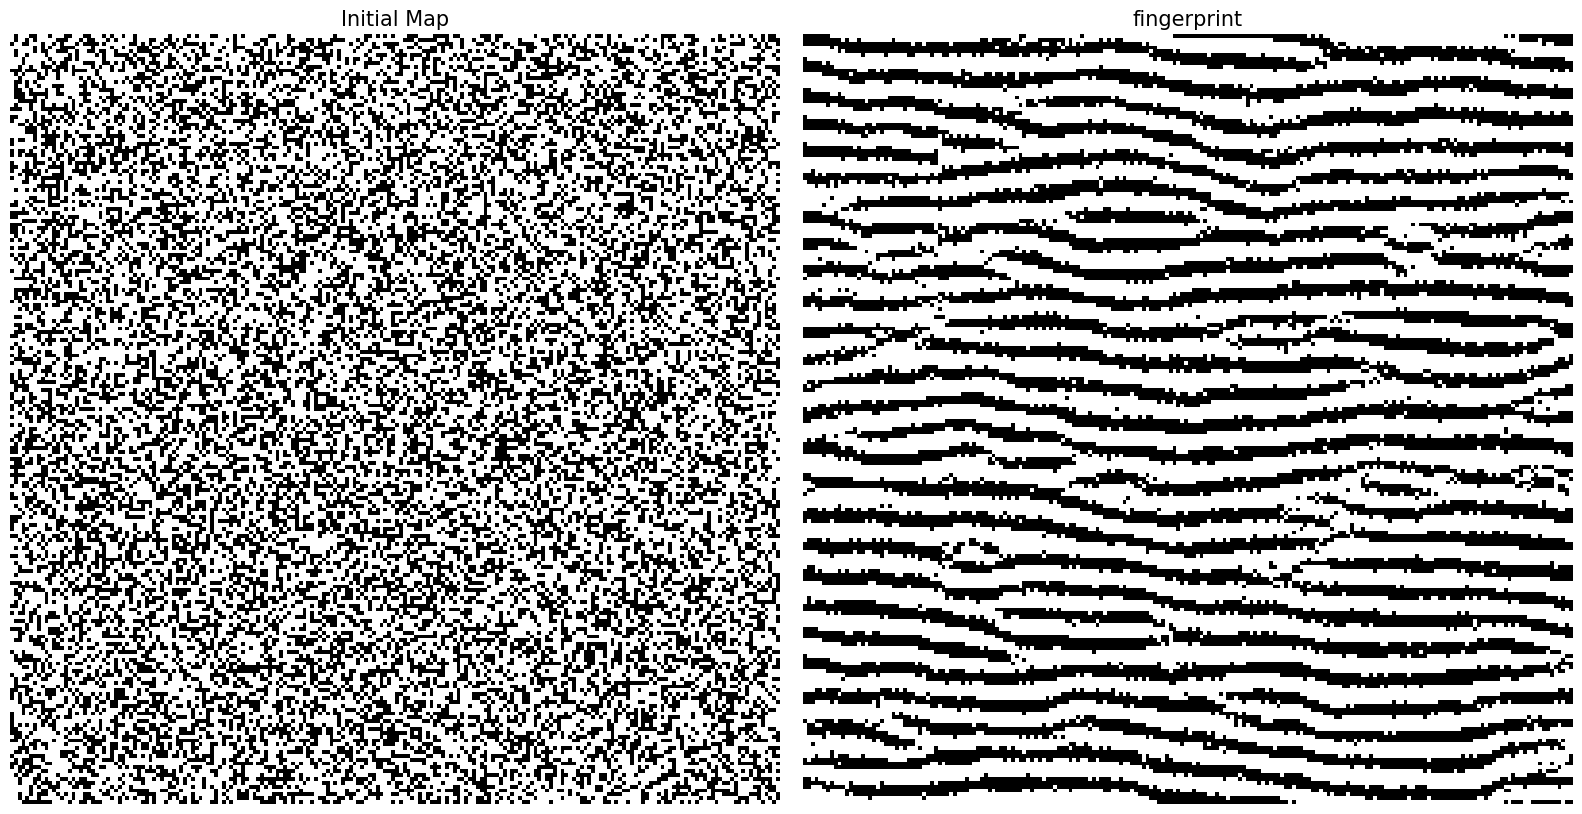

In [58]:
size = 200
density = 0.4
initial_map = generate_binary_map(size, density)

best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_fingerprint, 
    initial_temp=100.0, 
    cooling_rate=0.99988, 
    num_steps=600000
)
visualize_comparison(initial_map, best_img, "fingerprint")

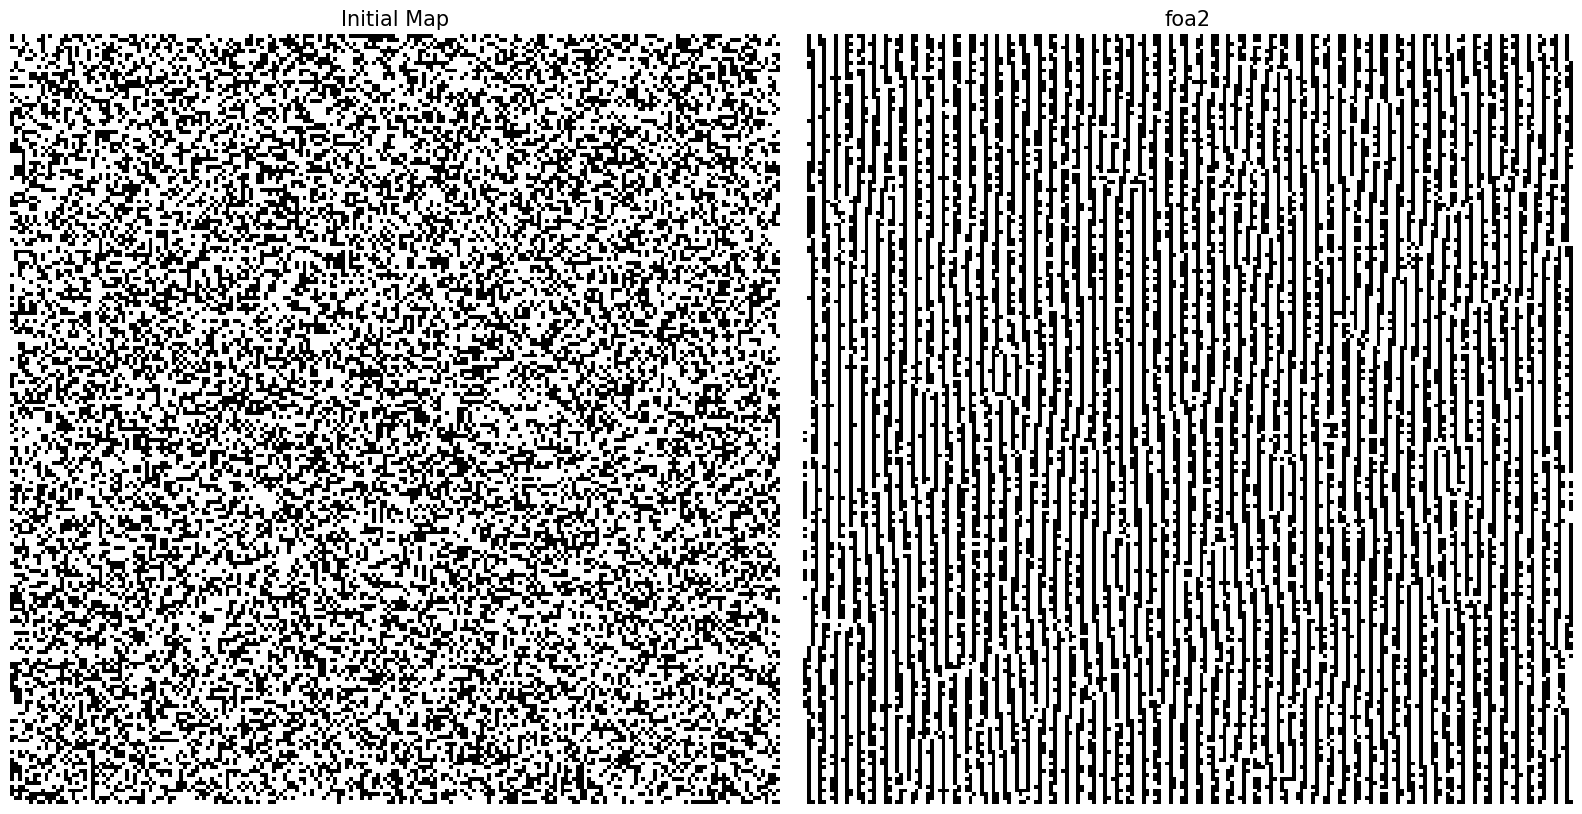

In [56]:
size = 200
density = 0.4
initial_map = generate_binary_map(size, density)

best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_foa2, 
    initial_temp=100.0, 
    cooling_rate=0.99988, 
    num_steps=600000
)
visualize_comparison(initial_map, best_img, "foa2")